Dataset Shape: (1073623, 6)
Classes: ['Walking' 'Jogging' 'Upstairs' 'Downstairs' 'Sitting' 'Standing']


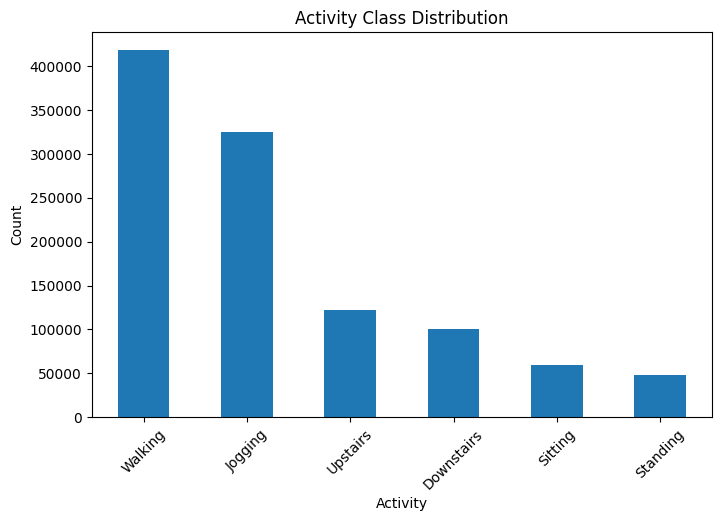

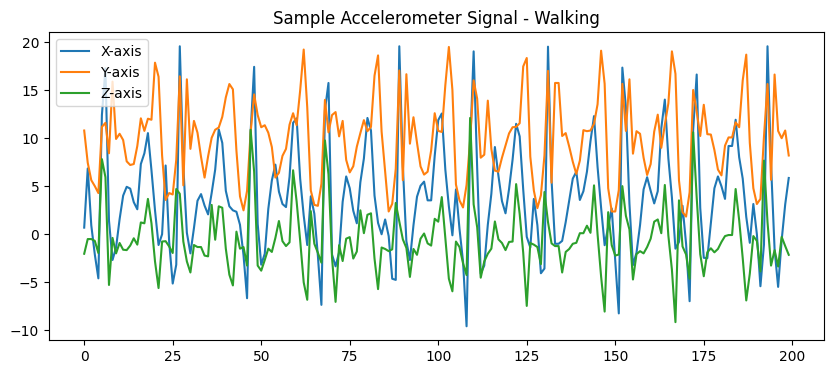

Encoded Classes: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']
Windowed Data Shape: (16774, 128, 3)
Using device: cuda
Epoch [1/10] Loss: 0.9655
Epoch [2/10] Loss: 0.6740
Epoch [3/10] Loss: 0.5489
Epoch [4/10] Loss: 0.4719
Epoch [5/10] Loss: 0.4114
Epoch [6/10] Loss: 0.3768
Epoch [7/10] Loss: 0.3452
Epoch [8/10] Loss: 0.3254
Epoch [9/10] Loss: 0.3060
Epoch [10/10] Loss: 0.2844


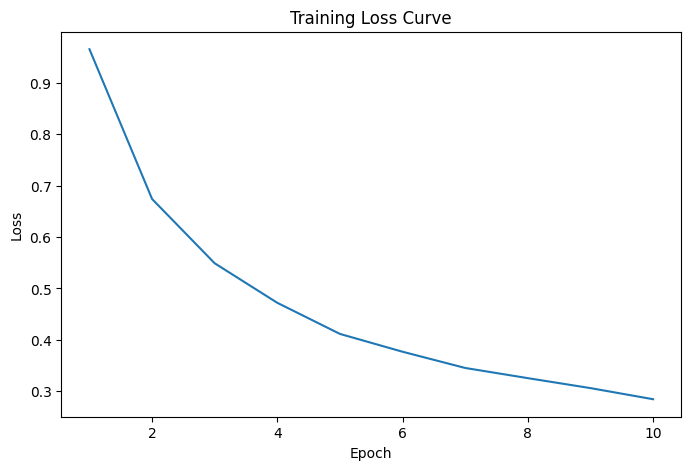


===== FINAL RESULTS =====
Accuracy: 0.8909090909090909
F1 Score: 0.8931406408178171

Classification Report:

              precision    recall  f1-score   support

  Downstairs       0.65      0.77      0.70       324
     Jogging       0.93      0.98      0.95       976
     Sitting       0.99      0.94      0.96       169
    Standing       0.94      0.94      0.94       162
    Upstairs       0.70      0.71      0.71       353
     Walking       0.97      0.89      0.93      1371

    accuracy                           0.89      3355
   macro avg       0.86      0.87      0.87      3355
weighted avg       0.90      0.89      0.89      3355



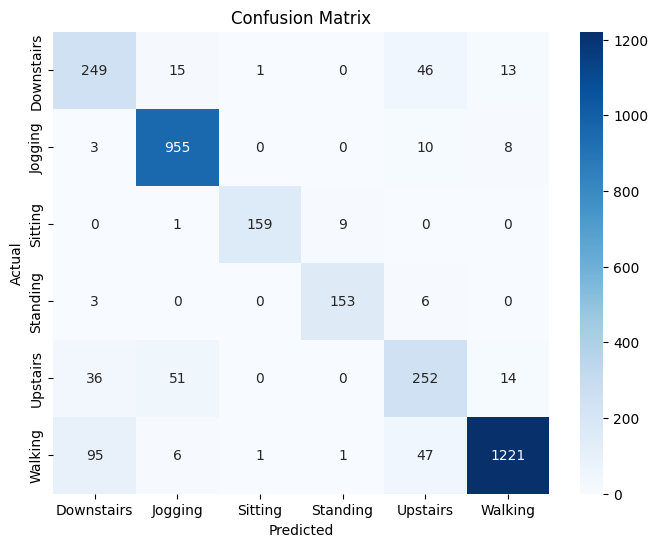

In [1]:
# =====================================================
# HUMAN ACTIVITY RECOGNITION USING SLIDING WINDOW
# TRANSFORMER SELF-ATTENTION (WISDM) + VISUALIZATION
# =====================================================

# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from torch.utils.data import Dataset, DataLoader

# ==============================
# 2. LOAD DATASET
# ==============================

path = "/kaggle/input/human-activity-recognition/time_series_data_human_activities.csv"
df = pd.read_csv(path)

print("Dataset Shape:", df.shape)
print("Classes:", df['activity'].unique())

# ==============================
# 3. VISUALIZATION (BEFORE PROCESSING)
# ==============================

# Class Distribution
plt.figure(figsize=(8,5))
df['activity'].value_counts().plot(kind='bar')
plt.title("Activity Class Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Sample Accelerometer Signal
sample_activity = "Walking"
sample = df[df['activity'] == sample_activity].iloc[:200]

plt.figure(figsize=(10,4))
plt.plot(sample['x-axis'], label='X-axis')
plt.plot(sample['y-axis'], label='Y-axis')
plt.plot(sample['z-axis'], label='Z-axis')
plt.title(f"Sample Accelerometer Signal - {sample_activity}")
plt.legend()
plt.show()

# ==============================
# 4. PREPROCESSING
# ==============================

# Noise removal
df[['x-axis','y-axis','z-axis']] = df[['x-axis','y-axis','z-axis']].rolling(3).mean()
df.dropna(inplace=True)

# Normalization
scaler = StandardScaler()
df[['x-axis','y-axis','z-axis']] = scaler.fit_transform(
    df[['x-axis','y-axis','z-axis']]
)

# Label Encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['activity'])
num_classes = len(le.classes_)

print("Encoded Classes:", le.classes_)

# ==============================
# 5. SLIDING WINDOW SEGMENTATION
# ==============================

window_size = 128
step_size = 64   # 50% overlap

X = []
y = []

data = df[['x-axis','y-axis','z-axis']].values
labels = df['label'].values

for i in range(0, len(data) - window_size, step_size):
    window = data[i:i+window_size]
    label = labels[i:i+window_size]
    X.append(window)
    y.append(np.bincount(label).argmax())

X = np.array(X)
y = np.array(y)

print("Windowed Data Shape:", X.shape)

# ==============================
# 6. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(HARDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(HARDataset(X_test, y_test), batch_size=64, shuffle=False)

# ==============================
# 7. TRANSFORMER MODEL
# ==============================

class HARTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=32, nhead=4, num_layers=1, num_classes=6):
        super(HARTransformer, self).__init__()
        
        self.embedding = nn.Linear(input_dim, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=64,
            dropout=0.1,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        self.fc = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global Average Pooling
        return self.fc(x)

# ==============================
# 8. TRAINING
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HARTransformer(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

# ==============================
# 9. TRAINING LOSS PLOT
# ==============================

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ==============================
# 10. EVALUATION
# ==============================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu()
        
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\n===== FINAL RESULTS =====")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# ==============================
# 11. CONFUSION MATRIX
# ==============================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create directory
save_path = "/kaggle/working/har_plots"
os.makedirs(save_path, exist_ok=True)

# =========================
# 1. Save Training Loss Plot
# =========================

plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(f"{save_path}/training_loss.png", dpi=300, bbox_inches="tight")
plt.close()

print("Training loss plot saved.")

# =========================
# 2. Save Confusion Matrix
# =========================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig(f"{save_path}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

print("Confusion matrix saved.")

# =========================
# 3. Save Class Distribution
# =========================

plt.figure(figsize=(8,5))
df['activity'].value_counts().plot(kind='bar')
plt.title("Activity Class Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig(f"{save_path}/class_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

print("Class distribution plot saved.")

print(f"\nAll plots saved in: {save_path}")


Training loss plot saved.
Confusion matrix saved.
Class distribution plot saved.

All plots saved in: /kaggle/working/har_plots
